# Notebook 1: Exploratory Data Analysis (EDA)
### NIFTY-50 Investment Intelligence Platform

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.data_loader import (load_metadata, load_stock, get_close_price_matrix,
                              get_daily_returns, get_sector_map, get_symbol_list)
from src.indicators import add_all_indicators

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
print("Imports OK")

Imports OK


## 1. Dataset Overview

In [3]:
meta = load_metadata()
sector_map = get_sector_map()
print(f"Total companies: {len(meta)}")
print(f"Sectors: {meta['Industry'].nunique()}")
print()
print(meta[['Symbol','Company Name','Industry']].to_string(index=False))

Total companies: 50
Sectors: 13

    Symbol                                 Company Name                 Industry
ADANIPORTS   Adani Ports and Special Economic Zone Ltd.                 SERVICES
ASIANPAINT                            Asian Paints Ltd.           CONSUMER GOODS
  AXISBANK                               Axis Bank Ltd.       FINANCIAL SERVICES
BAJAJ-AUTO                              Bajaj Auto Ltd.               AUTOMOBILE
BAJAJFINSV                           Bajaj Finserv Ltd.       FINANCIAL SERVICES
BAJFINANCE                           Bajaj Finance Ltd.       FINANCIAL SERVICES
BHARTIARTL                           Bharti Airtel Ltd.                  TELECOM
      BPCL            Bharat Petroleum Corporation Ltd.                   ENERGY
 BRITANNIA                    Britannia Industries Ltd.           CONSUMER GOODS
     CIPLA                                   Cipla Ltd.                   PHARMA
 COALINDIA                              Coal India Ltd.                   ME

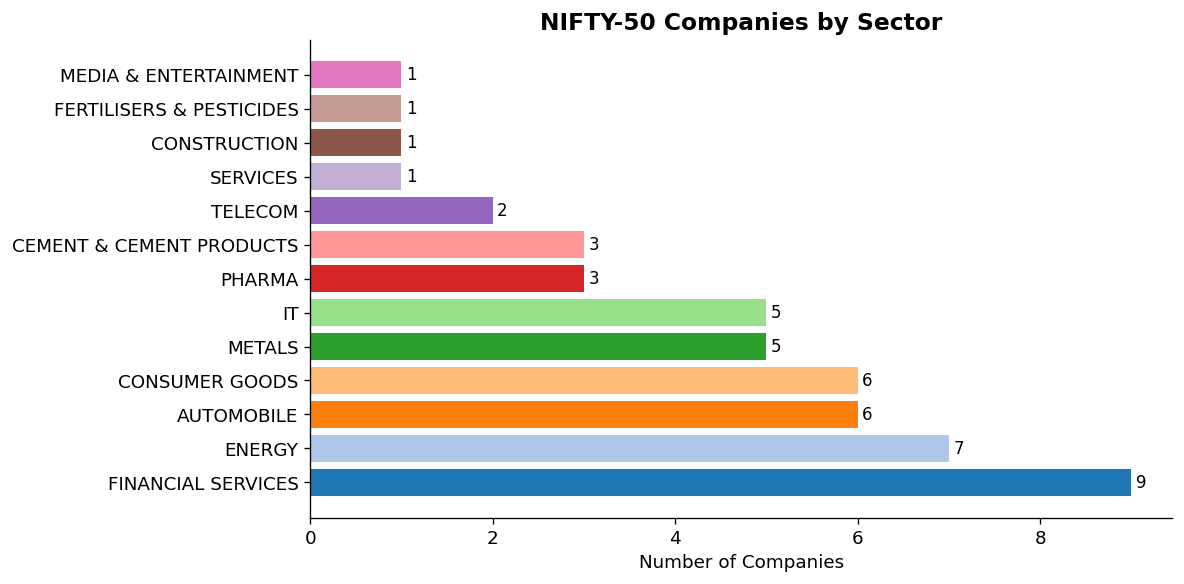

In [4]:
# Sector distribution
sector_counts = meta['Industry'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(sector_counts.index, sector_counts.values,
               color=plt.cm.tab20.colors[:len(sector_counts)])
ax.set_xlabel("Number of Companies")
ax.set_title("NIFTY-50 Companies by Sector", fontsize=14, fontweight='bold')
for bar, val in zip(bars, sector_counts.values):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)
plt.tight_layout()
plt.savefig('../report/sector_distribution.png', bbox_inches='tight')
plt.show()

## 2. Data Quality & Coverage

In [5]:
symbols = get_symbol_list()
coverage = {}
for sym in symbols:
    try:
        df = load_stock(sym)
        coverage[sym] = {
            'rows': len(df),
            'start': df['Date'].min().strftime('%Y-%m-%d'),
            'end':   df['Date'].max().strftime('%Y-%m-%d'),
            'missing_close': df['Close'].isna().sum(),
            'sector': sector_map.get(sym, 'Unknown')
        }
    except: pass

cov_df = pd.DataFrame(coverage).T.reset_index().rename(columns={'index':'Symbol'})
cov_df['rows'] = cov_df['rows'].astype(int)
print(f"Stocks with data: {len(cov_df)}")
print(f"\nDate range summary:")
print(f"  Earliest start: {cov_df['start'].min()}")
print(f"  Latest end:     {cov_df['end'].max()}")
print(f"\nRow count stats:")
print(cov_df['rows'].describe().to_string())

Stocks with data: 48

Date range summary:
  Earliest start: 2000-01-03
  Latest end:     2021-04-30

Row count stats:
count      48.000000
mean     4789.291667
std       796.822171
min      2598.000000
25%      4261.250000
50%      5305.500000
75%      5306.000000
max      5306.000000


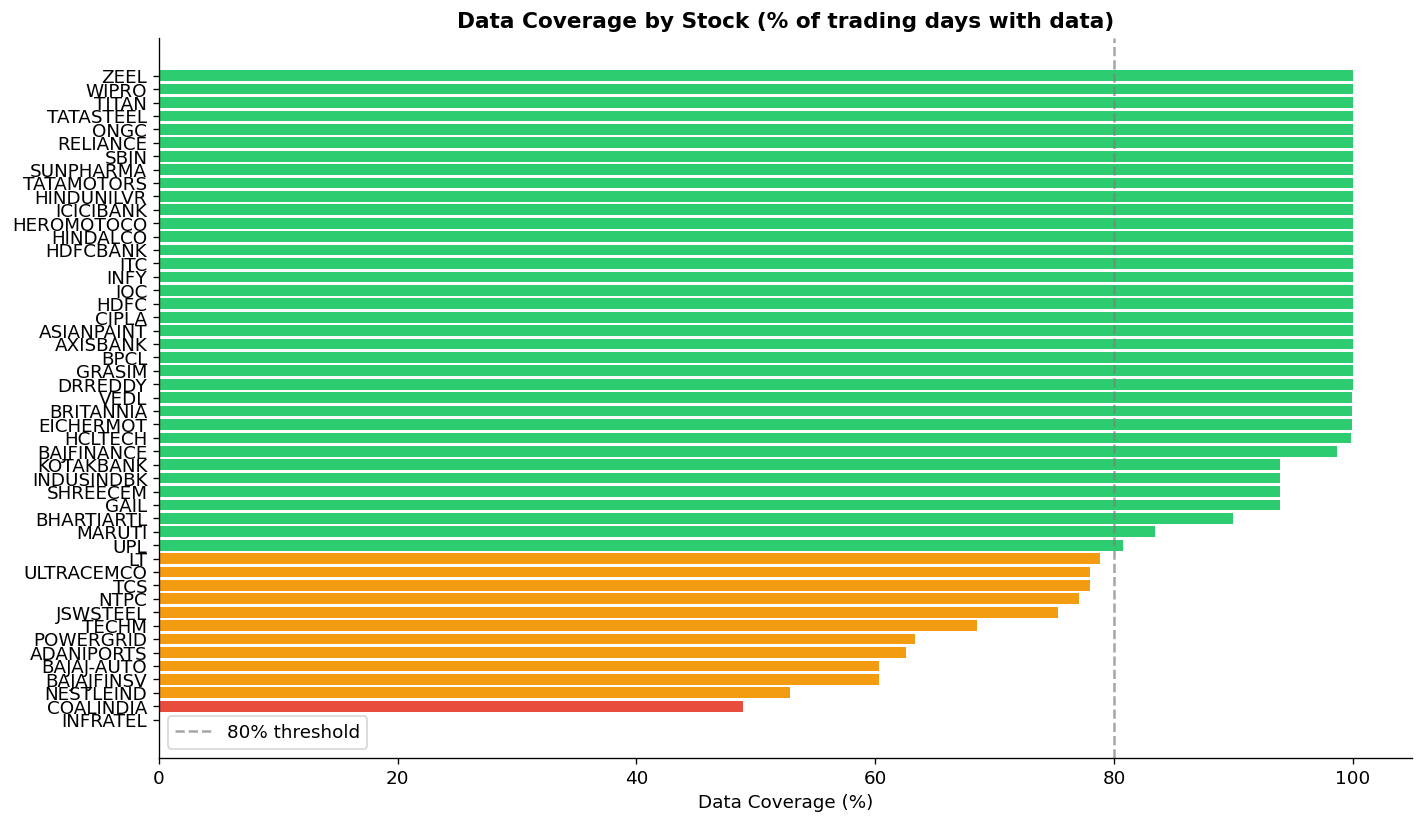

In [6]:
# Data coverage timeline
price_matrix = get_close_price_matrix()
coverage_pct = price_matrix.notna().sum() / len(price_matrix) * 100
coverage_pct_sorted = coverage_pct.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#e74c3c' if v < 50 else '#f39c12' if v < 80 else '#2ecc71'
          for v in coverage_pct_sorted.values]
bars = ax.barh(coverage_pct_sorted.index, coverage_pct_sorted.values, color=colors)
ax.axvline(x=80, color='gray', linestyle='--', alpha=0.7, label='80% threshold')
ax.set_xlabel("Data Coverage (%)")
ax.set_title("Data Coverage by Stock (% of trading days with data)", fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../report/data_coverage.png', bbox_inches='tight')
plt.show()

## 3. Price History Analysis

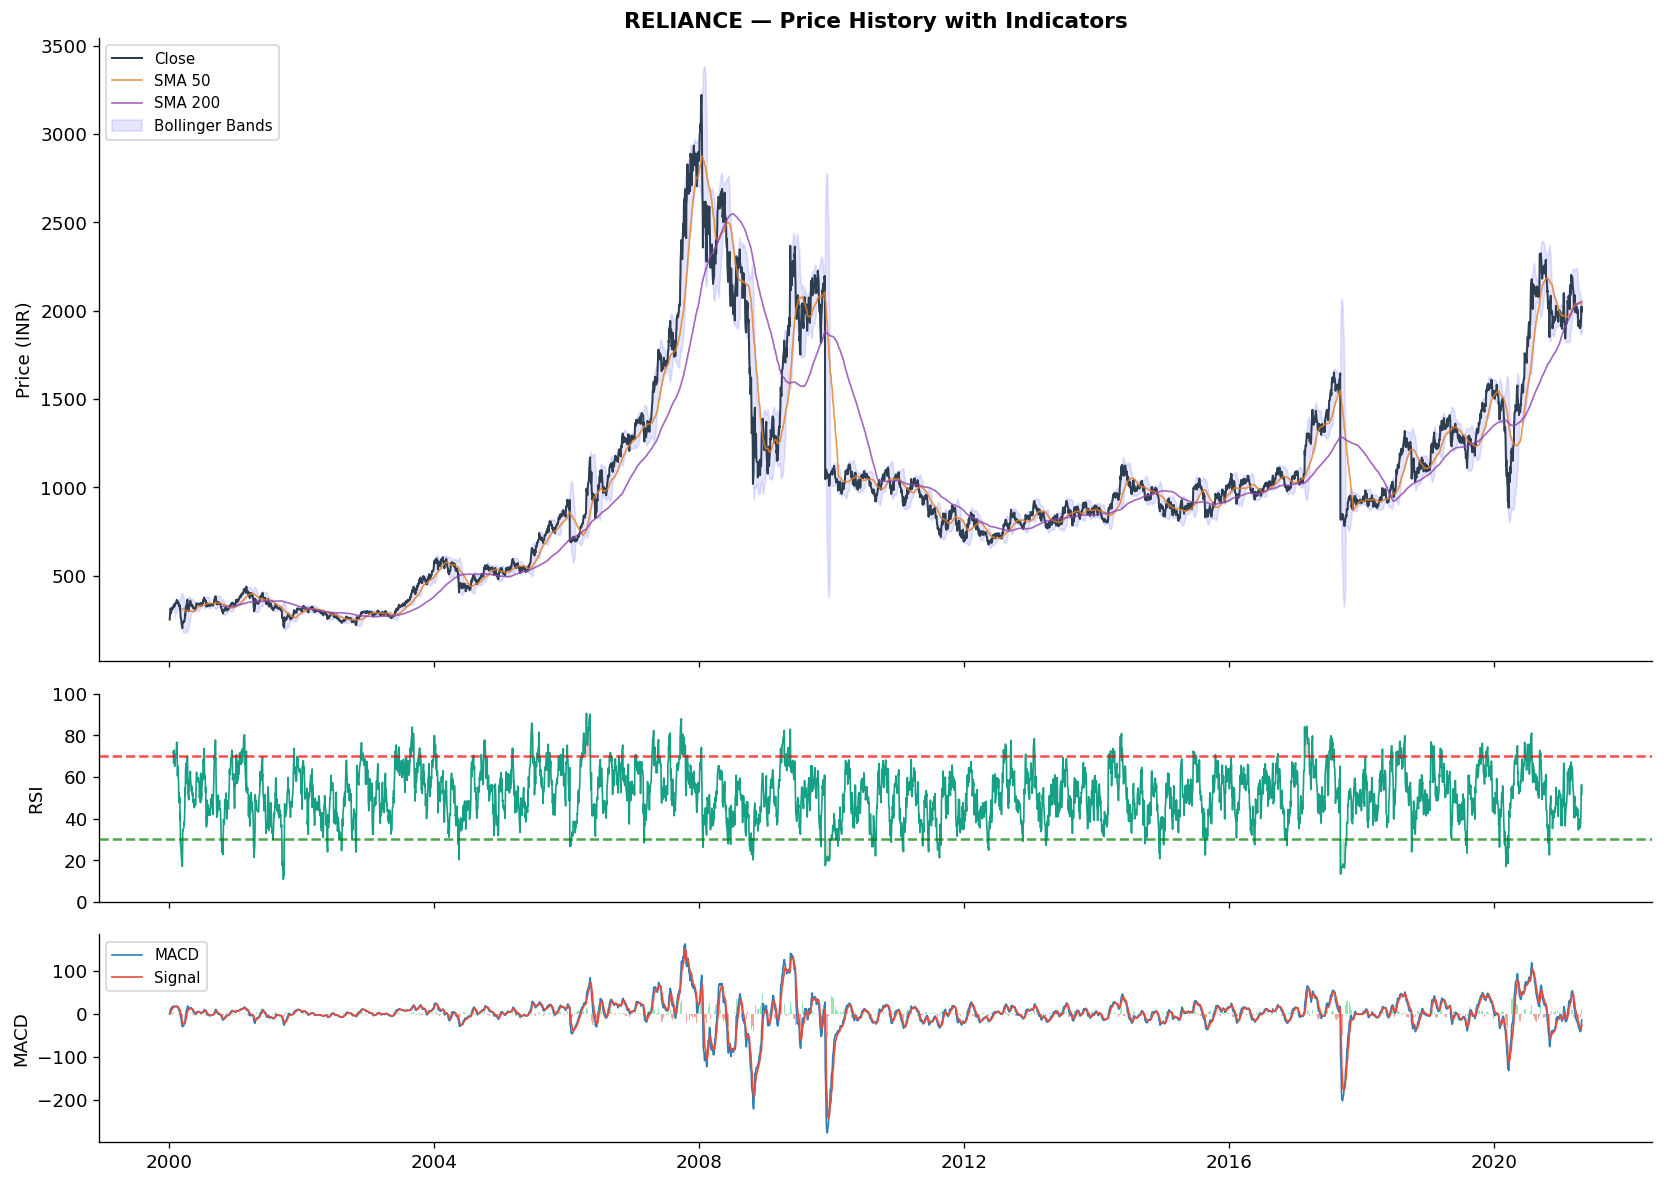

In [7]:
# Individual stock price chart - RELIANCE as example
df_rel = load_stock('RELIANCE')
df_rel = add_all_indicators(df_rel)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1, 1]})

# Price + Bollinger Bands
ax = axes[0]
ax.plot(df_rel['Date'], df_rel['Close'], color='#2c3e50', lw=1.2, label='Close')
ax.plot(df_rel['Date'], df_rel['SMA_50'], color='#e67e22', lw=1, alpha=0.8, label='SMA 50')
ax.plot(df_rel['Date'], df_rel['SMA_200'], color='#8e44ad', lw=1, alpha=0.8, label='SMA 200')
ax.fill_between(df_rel['Date'], df_rel['BB_Upper'], df_rel['BB_Lower'],
                alpha=0.1, color='blue', label='Bollinger Bands')
ax.set_ylabel("Price (INR)")
ax.set_title("RELIANCE — Price History with Indicators", fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)

# RSI
ax2 = axes[1]
ax2.plot(df_rel['Date'], df_rel['RSI'], color='#16a085', lw=1)
ax2.axhline(70, color='red', linestyle='--', alpha=0.7)
ax2.axhline(30, color='green', linestyle='--', alpha=0.7)
ax2.fill_between(df_rel['Date'], 70, df_rel['RSI'],
                 where=(df_rel['RSI'] >= 70), alpha=0.2, color='red')
ax2.fill_between(df_rel['Date'], 30, df_rel['RSI'],
                 where=(df_rel['RSI'] <= 30), alpha=0.2, color='green')
ax2.set_ylabel("RSI"); ax2.set_ylim(0, 100)

# MACD
ax3 = axes[2]
ax3.plot(df_rel['Date'], df_rel['MACD'], color='#2980b9', lw=1, label='MACD')
ax3.plot(df_rel['Date'], df_rel['MACD_Signal'], color='#e74c3c', lw=1, label='Signal')
ax3.bar(df_rel['Date'], df_rel['MACD_Hist'],
        color=df_rel['MACD_Hist'].apply(lambda x: '#2ecc71' if x >= 0 else '#e74c3c'),
        alpha=0.5, width=1)
ax3.set_ylabel("MACD"); ax3.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../report/reliance_indicators.png', bbox_inches='tight')
plt.show()

## 4. Sector Performance Analysis

In [8]:
# Compute total return for each stock (2000-2021)
total_returns = {}
for sym in symbols:
    try:
        df = load_stock(sym)
        if len(df) > 200:
            first = df['Close'].iloc[0]
            last  = df['Close'].iloc[-1]
            total_returns[sym] = (last - first) / first * 100
    except: pass

ret_df = pd.DataFrame.from_dict(total_returns, orient='index', columns=['Total_Return'])
ret_df['Sector'] = ret_df.index.map(sector_map)
ret_df = ret_df.sort_values('Total_Return', ascending=False)

print("Top 10 best performers (total return since listing):")
print(ret_df.head(10).to_string())
print("\nBottom 5:")
print(ret_df.tail(5).to_string())

Top 10 best performers (total return since listing):
            Total_Return                    Sector
SHREECEM    43005.019305  CEMENT & CEMENT PRODUCTS
BAJFINANCE  10642.660099        FINANCIAL SERVICES
EICHERMOT    4857.318321                AUTOMOBILE
MARUTI       3829.184419                AUTOMOBILE
INDUSINDBK   3129.533679        FINANCIAL SERVICES
AXISBANK     2577.528090        FINANCIAL SERVICES
ULTRACEMCO   2313.124520  CEMENT & CEMENT PRODUCTS
BAJAJFINSV   2068.856806        FINANCIAL SERVICES
BHARTIARTL   1110.259301                   TELECOM
TITAN         858.028259            CONSUMER GOODS

Bottom 5:
       Total_Return                 Sector
IOC      -66.457449                 ENERGY
ITC      -71.404375         CONSUMER GOODS
WIPRO    -81.912121                     IT
ZEEL     -84.270520  MEDIA & ENTERTAINMENT
INFY     -91.332271                     IT


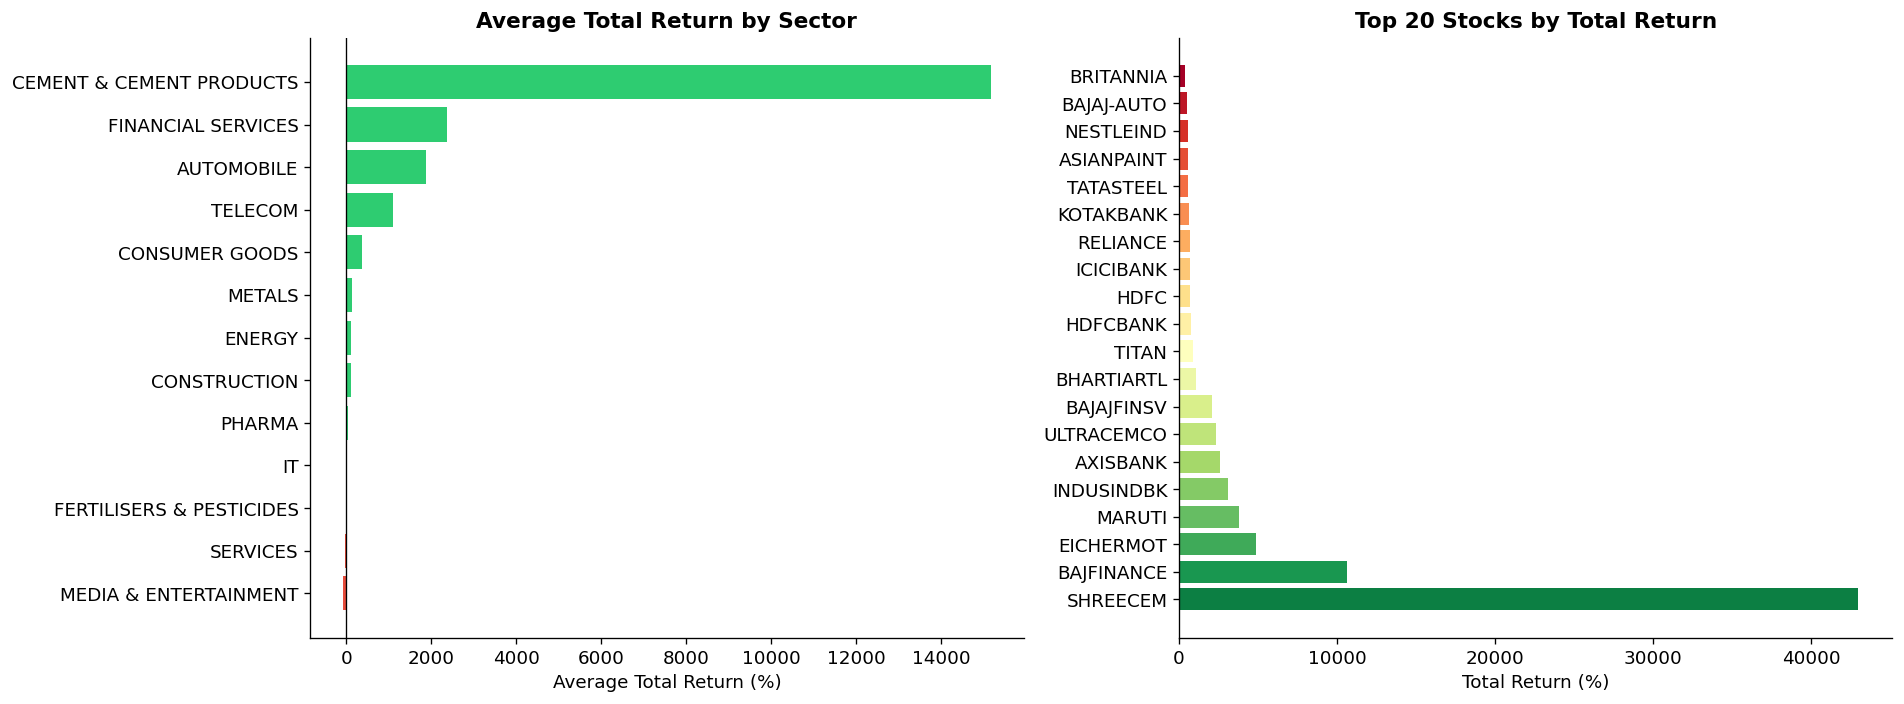

In [9]:
# Sector-wise average returns
sector_ret = ret_df.groupby('Sector')['Total_Return'].mean().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sector returns
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in sector_ret.values]
axes[0].barh(sector_ret.index, sector_ret.values, color=colors)
axes[0].set_xlabel("Average Total Return (%)")
axes[0].set_title("Average Total Return by Sector", fontsize=13, fontweight='bold')
axes[0].axvline(x=0, color='black', lw=0.8)

# Individual stock returns (top 20)
top20 = ret_df.head(20)
bar_colors = [plt.cm.RdYlGn(i/20) for i in range(len(top20))][::-1]
axes[1].barh(top20.index, top20['Total_Return'], color=bar_colors)
axes[1].set_xlabel("Total Return (%)")
axes[1].set_title("Top 20 Stocks by Total Return", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../report/sector_returns.png', bbox_inches='tight')
plt.show()

## 5. Correlation & Co-movement Analysis

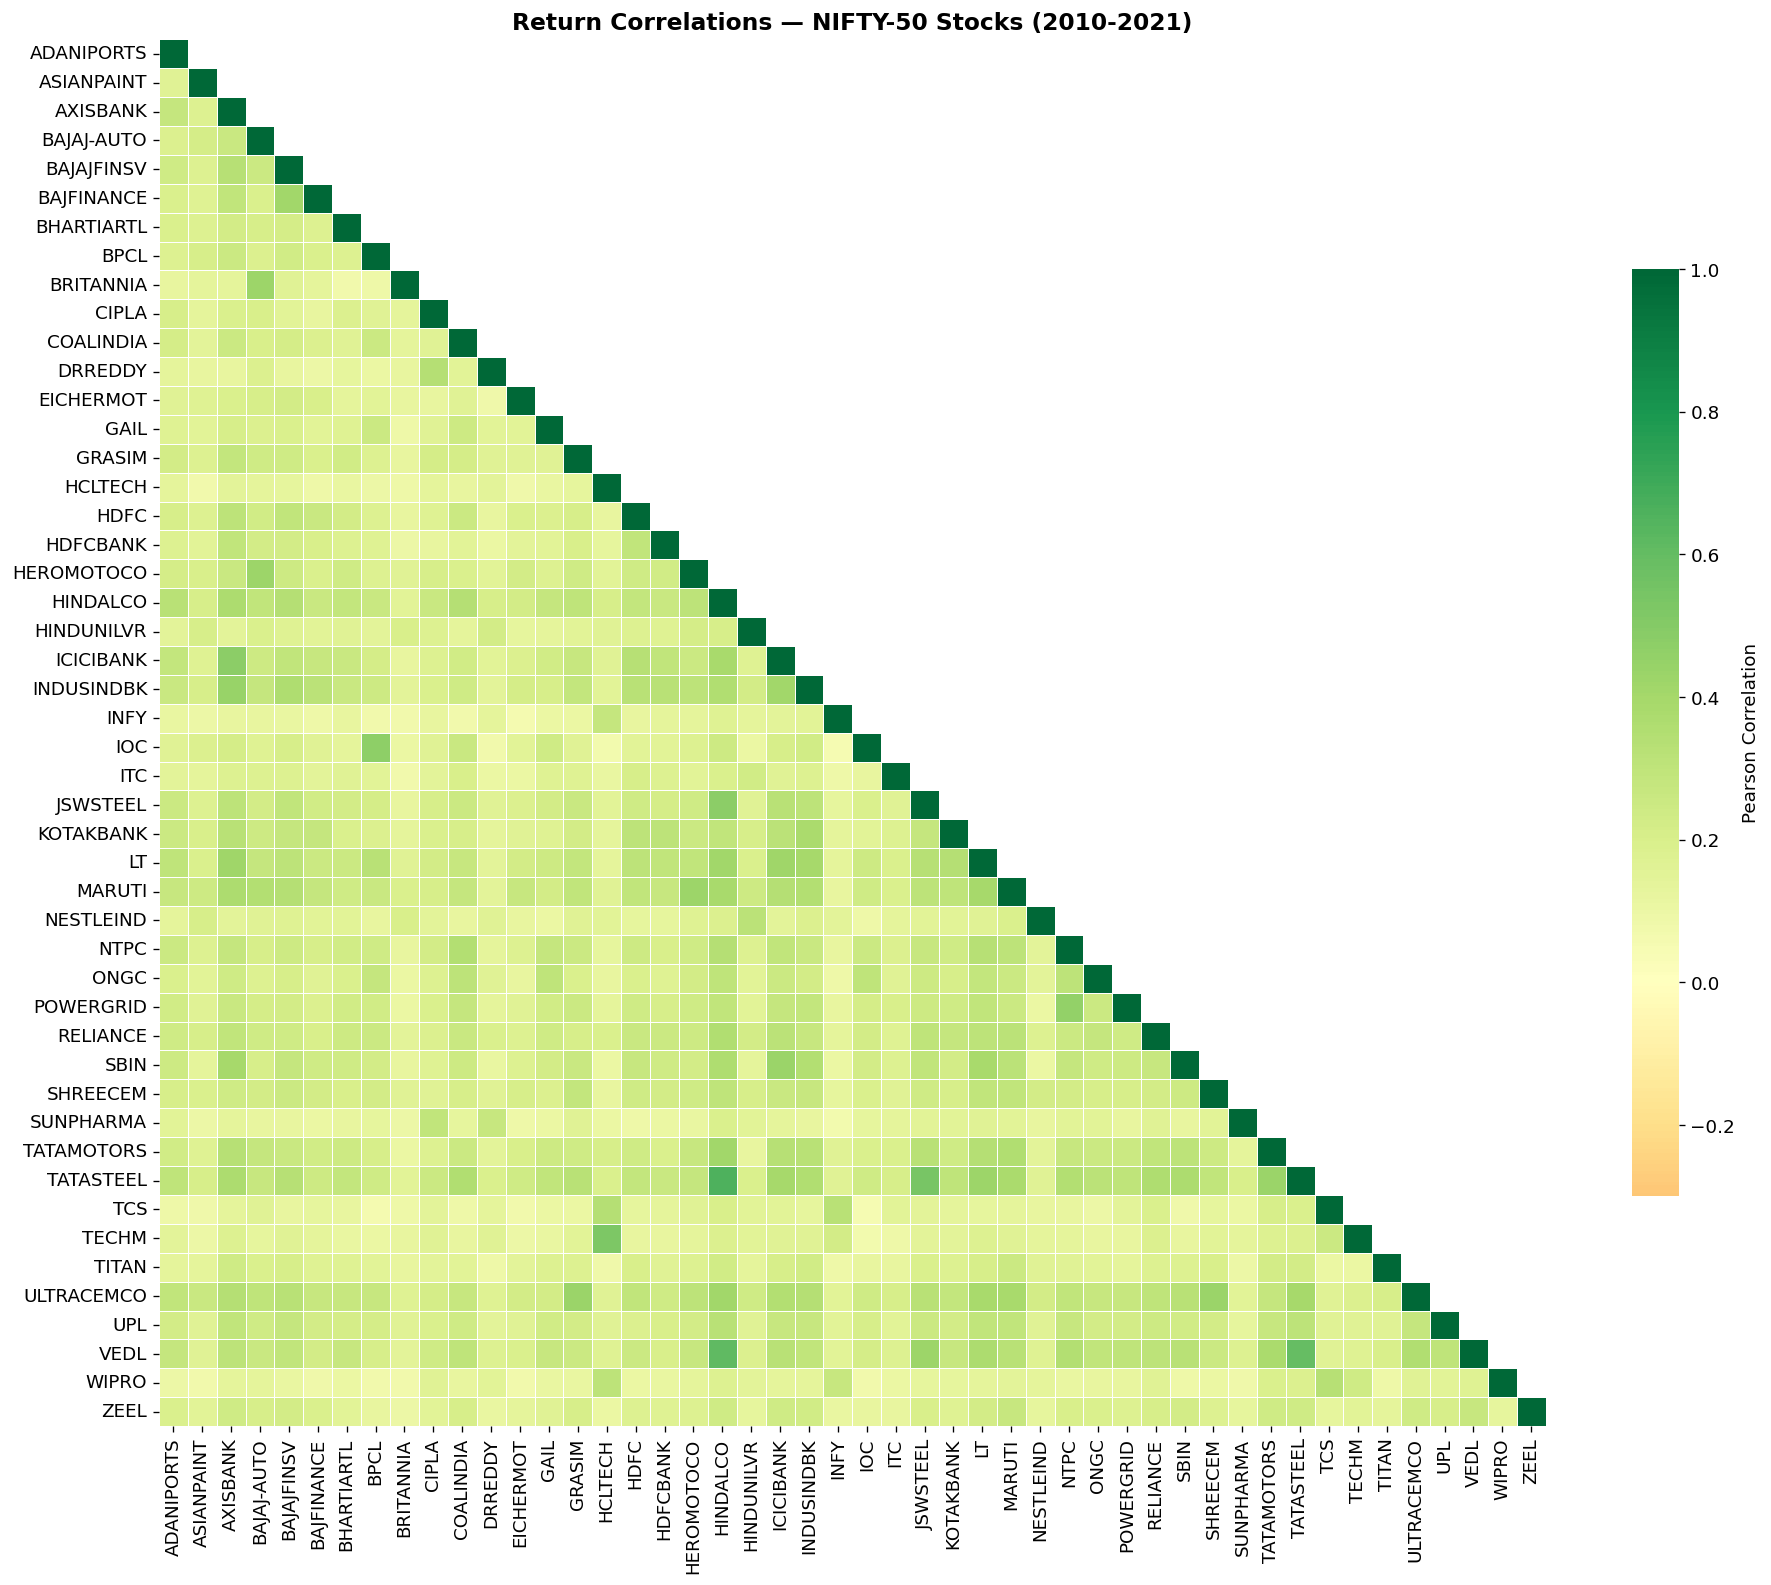

In [10]:
# Correlation heatmap of daily returns
# Use 2010-2021 for cleaner cross-section
daily_ret = get_daily_returns(start_date='2010-01-01')
daily_ret = daily_ret.dropna(thresh=int(0.8 * len(daily_ret)), axis=1)

corr_matrix = daily_ret.corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, cmap='RdYlGn', center=0,
            vmin=-0.3, vmax=1.0, ax=ax,
            linewidths=0.3, square=True,
            cbar_kws={'shrink': 0.6, 'label': 'Pearson Correlation'})
ax.set_title("Return Correlations — NIFTY-50 Stocks (2010-2021)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/correlation_heatmap.png', bbox_inches='tight')
plt.show()

In [11]:
# Sector-level correlation (average within vs across)
sector_list = sorted(set(sector_map.values()))
syms_with_data = [s for s in daily_ret.columns if s in sector_map]

sector_corr_data = {}
for s in sector_list:
    sector_syms = [sym for sym in syms_with_data if sector_map.get(sym) == s]
    if len(sector_syms) >= 2:
        sub = corr_matrix.loc[sector_syms, sector_syms]
        mask_upper = np.triu(np.ones(sub.shape, dtype=bool), k=1)
        vals = sub.values[mask_upper]
        sector_corr_data[s] = vals.mean()

sc_df = pd.Series(sector_corr_data).sort_values(ascending=False)
print("Average intra-sector return correlation:")
print(sc_df.to_string())

Average intra-sector return correlation:
METALS                      0.457676
CEMENT & CEMENT PRODUCTS    0.384678
FINANCIAL SERVICES          0.316192
IT                          0.309800
PHARMA                      0.301091
AUTOMOBILE                  0.300372
ENERGY                      0.275962
CONSUMER GOODS              0.170218


## 6. Volatility Analysis

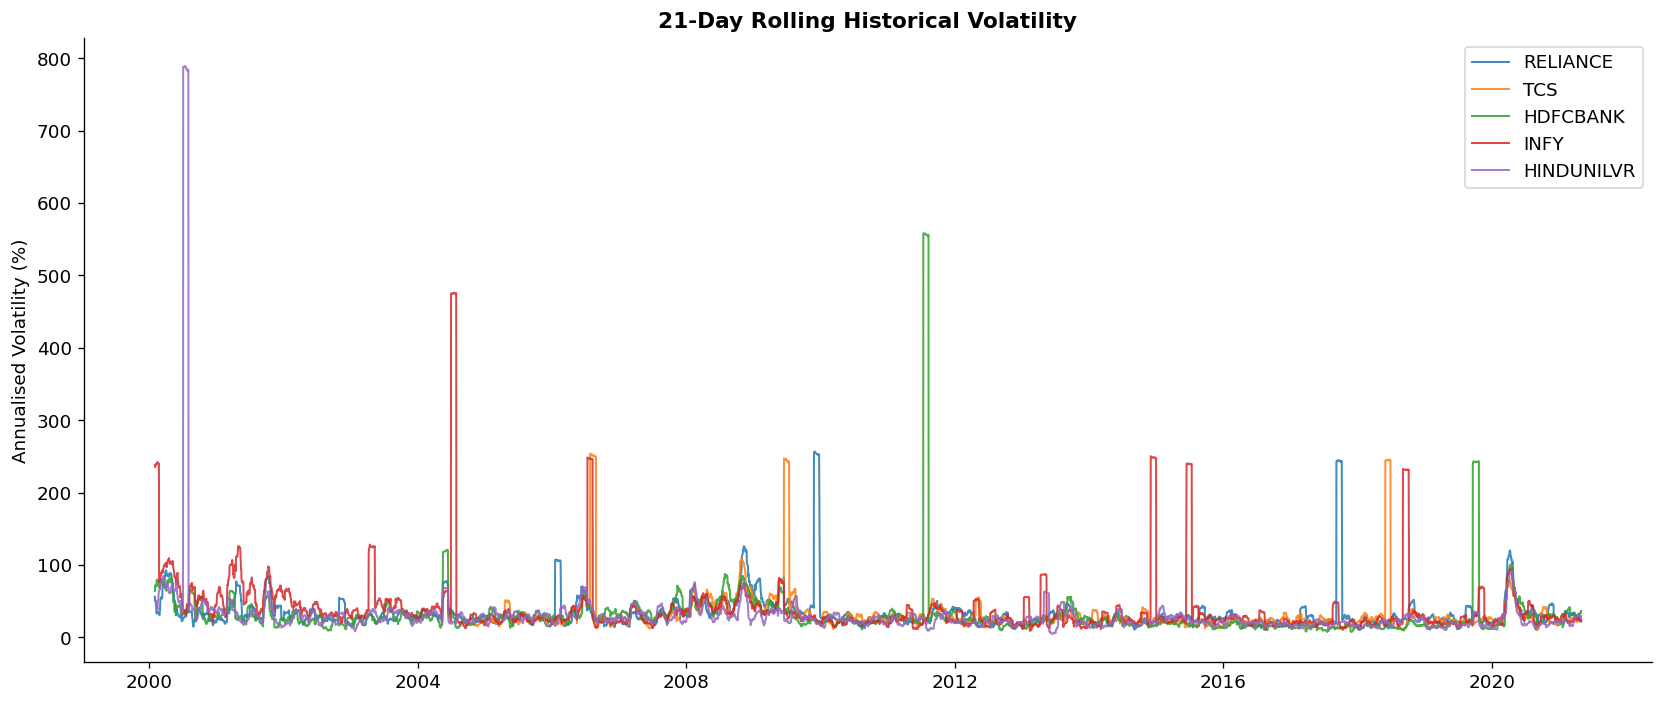

In [12]:
# Rolling volatility for key stocks
key_stocks = ['RELIANCE', 'TCS', 'HDFCBANK', 'INFY', 'HINDUNILVR']
fig, ax = plt.subplots(figsize=(14, 6))

for sym in key_stocks:
    df_s = load_stock(sym)
    df_s = add_all_indicators(df_s)
    df_s = df_s.dropna(subset=['HV_21'])
    ax.plot(df_s['Date'], df_s['HV_21'], lw=1.2, label=sym, alpha=0.85)

ax.set_ylabel("Annualised Volatility (%)")
ax.set_title("21-Day Rolling Historical Volatility", fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../report/rolling_volatility.png', bbox_inches='tight')
plt.show()

In [13]:
# Volatility summary table
vol_summary = {}
for sym in symbols:
    try:
        df_s = load_stock(sym)
        log_ret = np.log(df_s['Close'] / df_s['Close'].shift(1)).dropna()
        vol_summary[sym] = {
            'Ann_Vol_%': round(log_ret.std() * np.sqrt(252) * 100, 2),
            'Skewness':  round(log_ret.skew(), 3),
            'Kurtosis':  round(log_ret.kurt(), 3),
            'Sector':    sector_map.get(sym, '?')
        }
    except: pass

vol_df = pd.DataFrame(vol_summary).T.reset_index().rename(columns={'index':'Symbol'})
vol_df['Ann_Vol_%'] = vol_df['Ann_Vol_%'].astype(float)
vol_df_sorted = vol_df.sort_values('Ann_Vol_%', ascending=False)
print("Most volatile stocks:")
print(vol_df_sorted.head(10)[['Symbol','Sector','Ann_Vol_%','Skewness','Kurtosis']].to_string(index=False))
print("\nLeast volatile:")
print(vol_df_sorted.tail(5)[['Symbol','Sector','Ann_Vol_%']].to_string(index=False))

Most volatile stocks:
    Symbol             Sector  Ann_Vol_% Skewness  Kurtosis
      VEDL             METALS      83.62  -33.046  1822.628
     TITAN     CONSUMER GOODS      78.22  -39.628  2363.569
  JSWSTEEL             METALS      74.63  -29.712  1463.878
       ITC     CONSUMER GOODS      67.26  -45.691  2780.003
BAJFINANCE FINANCIAL SERVICES      66.78   -30.47   1659.22
 EICHERMOT         AUTOMOBILE      66.32  -31.347  1735.127
  HINDALCO             METALS      65.59  -31.688  1746.179
      SBIN FINANCIAL SERVICES      62.42  -36.825  2139.614
ADANIPORTS           SERVICES      61.80  -21.699   904.239
 SUNPHARMA             PHARMA      61.27  -21.436    762.94

Least volatile:
   Symbol         Sector  Ann_Vol_%
     NTPC         ENERGY      30.24
COALINDIA         METALS      29.85
POWERGRID         ENERGY      29.77
NESTLEIND CONSUMER GOODS      24.15
 INFRATEL        TELECOM        NaN


## 7. Return Distribution Analysis

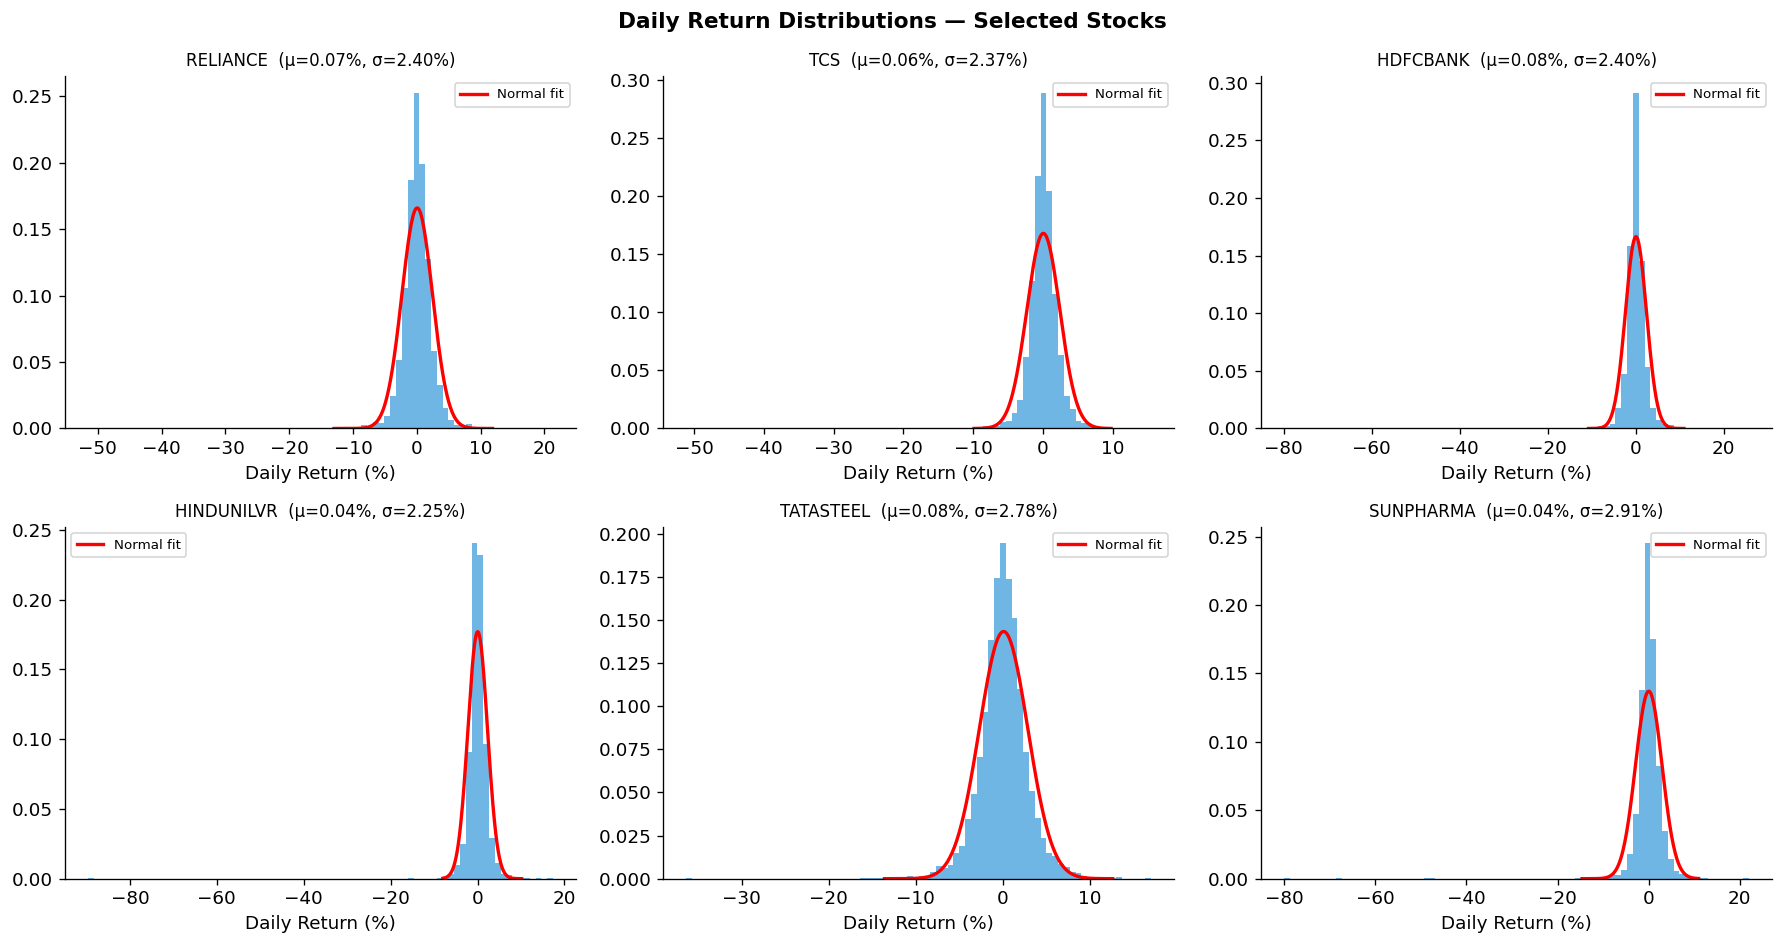

In [14]:
from scipy import stats

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

sample_stocks = ['RELIANCE','TCS','HDFCBANK','HINDUNILVR','TATASTEEL','SUNPHARMA']
for i, sym in enumerate(sample_stocks):
    df_s = load_stock(sym)
    daily_r = df_s['Close'].pct_change().dropna() * 100
    ax = axes[i]
    ax.hist(daily_r, bins=80, color='#3498db', alpha=0.7, density=True, edgecolor='none')
    mu, sigma = daily_r.mean(), daily_r.std()
    x = np.linspace(daily_r.quantile(0.001), daily_r.quantile(0.999), 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2, label='Normal fit')
    ax.set_title(f"{sym}  (μ={mu:.2f}%, σ={sigma:.2f}%)", fontsize=10)
    ax.set_xlabel("Daily Return (%)"); ax.legend(fontsize=8)

plt.suptitle("Daily Return Distributions — Selected Stocks", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/return_distributions.png', bbox_inches='tight')
plt.show()

## 8. Market Cycle Detection

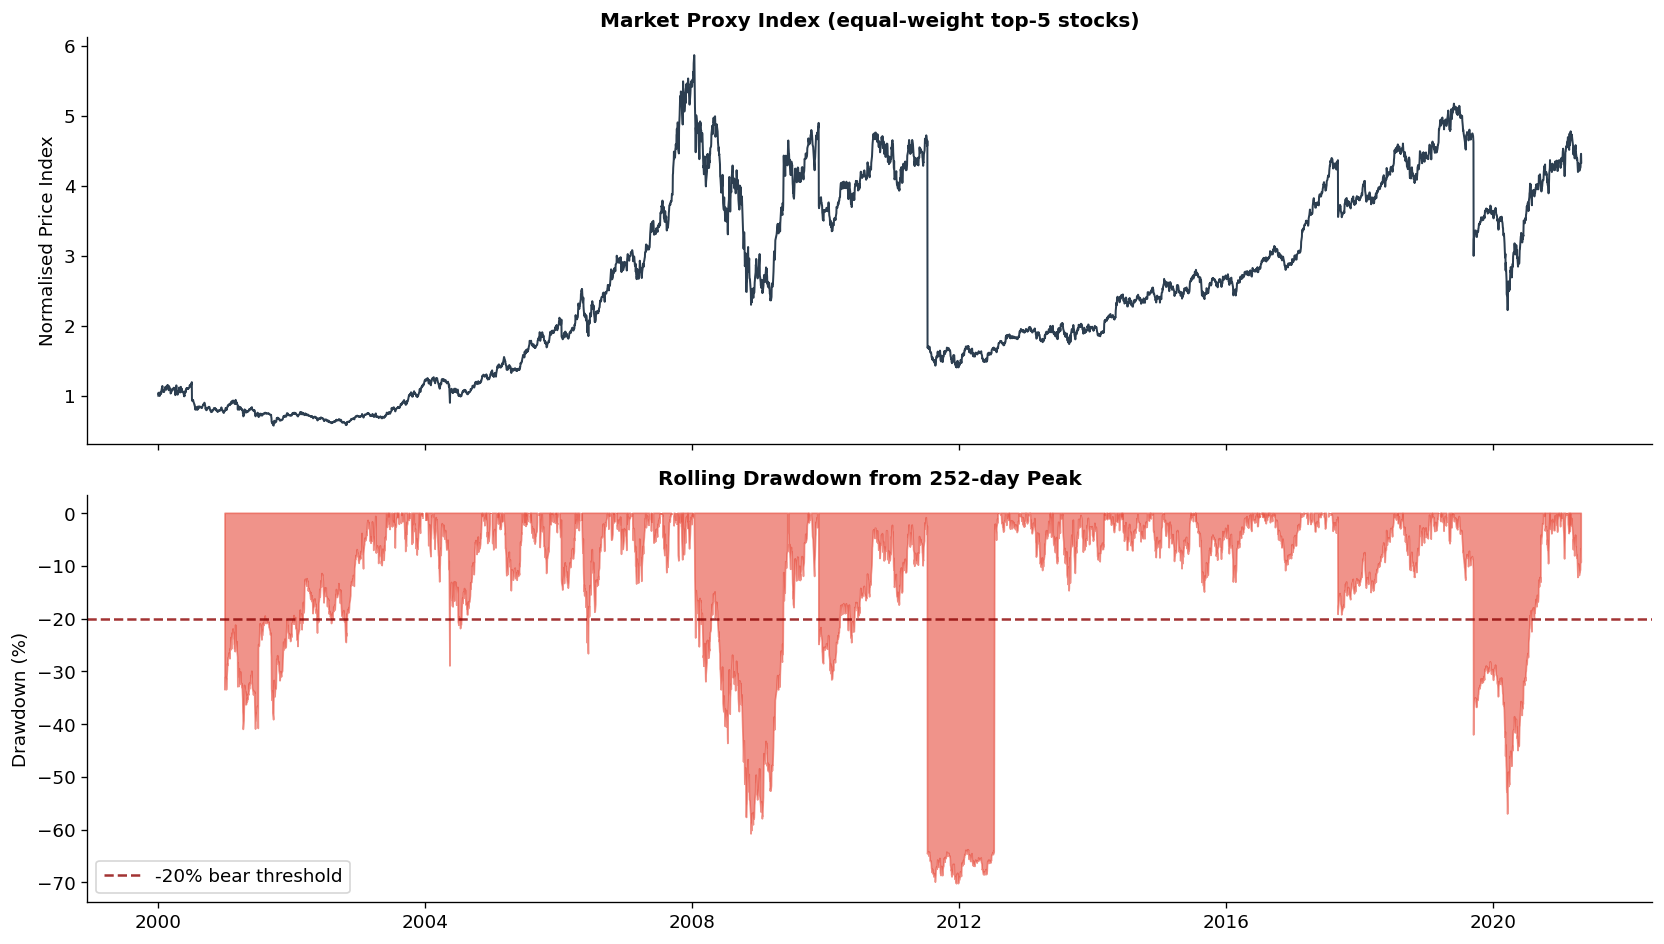

In [15]:
# Bull/Bear market periods using Nifty-proxied index (RELIANCE as anchor)
# We'll use aggregate of top 5 stocks as a market proxy
proxy_stocks = ['RELIANCE','TCS','HDFCBANK','INFY','HINDUNILVR']
prices = get_close_price_matrix(proxy_stocks, start_date='2000-01-01')
prices = prices.dropna(how='all')
# Normalise and average
normed = prices / prices.iloc[0]
market_index = normed.mean(axis=1)

rolling_peak = market_index.rolling(252).max()
drawdown = (market_index - rolling_peak) / rolling_peak * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(market_index.index, market_index, color='#2c3e50', lw=1.2)
axes[0].set_ylabel("Normalised Price Index")
axes[0].set_title("Market Proxy Index (equal-weight top-5 stocks)", fontsize=12, fontweight='bold')

axes[1].fill_between(drawdown.index, drawdown, 0,
                     where=(drawdown < 0), color='#e74c3c', alpha=0.6)
axes[1].axhline(-20, color='darkred', linestyle='--', alpha=0.8, label='-20% bear threshold')
axes[1].set_ylabel("Drawdown (%)"); axes[1].legend()
axes[1].set_title("Rolling Drawdown from 252-day Peak", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../report/market_cycles.png', bbox_inches='tight')
plt.show()

## 9. Key EDA Findings Summary

In [16]:
print("=" * 60)
print("KEY EDA FINDINGS")
print("=" * 60)

print(f"\n1. Dataset: {len(symbols)} stocks, spanning Jan 2000 - Apr 2021")
print(f"   Sectors covered: {meta['Industry'].nunique()}")

avg_corr = corr_matrix.values[np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)].mean()
print(f"\n2. Average pairwise return correlation: {avg_corr:.3f}")
print("   -> Moderate positive correlation indicates diversification is limited")
print("      but still valuable across sectors.")

best = ret_df['Total_Return'].idxmax()
worst = ret_df['Total_Return'].idxmin()
print(f"\n3. Best long-term performer: {best} ({ret_df.loc[best,'Total_Return']:.0f}% total return)")
print(f"   Worst long-term performer: {worst} ({ret_df.loc[worst,'Total_Return']:.0f}% total return)")

most_vol = vol_df_sorted.iloc[0]['Symbol']
least_vol = vol_df_sorted.iloc[-1]['Symbol']
print(f"\n4. Most volatile: {most_vol} ({vol_df_sorted.iloc[0]['Ann_Vol_%']:.1f}% annual vol)")
print(f"   Least volatile: {least_vol} ({vol_df_sorted.iloc[-1]['Ann_Vol_%']:.1f}% annual vol)")

print("\n5. Return distributions show fat tails and negative skewness")
print("   -> Normal distribution underestimates tail risk")
print("   -> Supports use of Sortino ratio and CVaR for risk assessment")

print("\n6. Market cycles visible: 2008 GFC, 2013 taper tantrum, 2020 COVID crash")
print("   -> Drawdown analysis critical for portfolio stress testing")

KEY EDA FINDINGS

1. Dataset: 49 stocks, spanning Jan 2000 - Apr 2021
   Sectors covered: 13

2. Average pairwise return correlation: 0.206
   -> Moderate positive correlation indicates diversification is limited
      but still valuable across sectors.

3. Best long-term performer: SHREECEM (43005% total return)
   Worst long-term performer: INFY (-91% total return)

4. Most volatile: VEDL (83.6% annual vol)
   Least volatile: INFRATEL (nan% annual vol)

5. Return distributions show fat tails and negative skewness
   -> Normal distribution underestimates tail risk
   -> Supports use of Sortino ratio and CVaR for risk assessment

6. Market cycles visible: 2008 GFC, 2013 taper tantrum, 2020 COVID crash
   -> Drawdown analysis critical for portfolio stress testing
